# Generación de Texto con Transformer

## Descripción del Problema

En este notebook implementaremos un modelo Transformer para generar texto autoregresivamente utilizando el dataset de reseñas de cine IMDb. El modelo aprenderá a predecir la siguiente palabra en una secuencia y generará reseñas coherentes.

## Arquitectura

El Transformer utiliza:
- **Multi-Head Self-Attention**: Permite ponderar la importancia de cada palabra respecto a las demás.
- **Positional Encoding**: Añade información de posición a los tokens.
- **Feed-Forward Networks**: Transforma las representaciones aprendidas.
- **Decodificador autoregresivo**: Genera texto palabra por palabra.

## Resultados del Transformer

### Ejemplos de Texto Generado

Los ejemplos muestran reseñas generadas por el modelo Transformer después del entrenamiento. El modelo ha aprendido la estructura y estilo del lenguaje de las reseñas de cine.

### Ventajas del Transformer

- **Procesamiento paralelo**: Entrenamiento más rápido que RNN/LSTM.
- **Mejor manejo de dependencias largas**: La atención global captura relaciones entre palabras distantes.
- **Calidad de generación superior**: Textos más coherentes y con mejor estructura.

In [1]:
# ========================================
# IMPORTACIÓN DE LIBRERÍAS Y CARGA DE DATOS
# ========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import re
import kagglehub

from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, LayerNormalization, Embedding, MultiHeadAttention, Add, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Configuración
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

# Cargar dataset
print("Cargando dataset...")
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")
file_path = os.path.join(path, "IMDB Dataset.csv")
df = pd.read_csv(file_path)

print(f"Dataset cargado: {df.shape[0]} registros")
print(df.head())

Cargando dataset...
Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Dataset cargado: 50000 registros
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [2]:
# ========================================
# PREPROCESAMIENTO PARA GENERACIÓN DE TEXTO
# ========================================

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Configuración
VOCAB_SIZE = 10000
MAX_LENGTH = 50
NUM_SAMPLES = 10000  # Usamos 10k reseñas para que sea más rápido

# Limpiar texto (misma función del Notebook 1)
def limpiar_texto(texto):
    texto = re.sub(r'<.*?>', ' ', texto)
    texto = texto.lower()
    texto = re.sub(r'[^a-zA-Z\s]', '', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

# Aplicar limpieza y tomar primeras 10,000 reseñas
print("Limpiando texto...")
df['review_clean'] = df['review'].apply(limpiar_texto)
texts = df['review_clean'].iloc[:NUM_SAMPLES].tolist()

# Tokenización
print("Creando vocabulario...")
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(texts)
word_index = tokenizer.word_index

print(f"Tamaño del vocabulario: {len(word_index)} palabras")

# Convertir texto a secuencias de números
print("Convirtiendo texto a secuencias...")
sequences = tokenizer.texts_to_sequences(texts)

# Padding
print("Aplicando padding...")
sequences_padded = pad_sequences(sequences, maxlen=MAX_LENGTH, padding='post', truncating='post')

print(f"Forma de los datos: {sequences_padded.shape}")

# Crear pares (entrada, salida) para entrenamiento autoregresivo
# Entrada: palabras 0 a n-1, Salida: palabras 1 a n
X = sequences_padded[:, :-1]  # Todas las columnas excepto la última
y = sequences_padded[:, 1:]   # Todas las columnas excepto la primera

print(f"X shape: {X.shape}")  # (num_samples, 49)
print(f"y shape: {y.shape}")  # (num_samples, 49)

# Verificar una muestra
print("\n=== EJEMPLO DE SECUENCIA ===")
print("Secuencia original:", sequences_padded[0][:20])
print("X (entrada):", X[0][:10])
print("y (salida):", y[0][:10])

Limpiando texto...
Creando vocabulario...
Tamaño del vocabulario: 67983 palabras
Convirtiendo texto a secuencias...
Aplicando padding...
Forma de los datos: (10000, 50)
X shape: (10000, 49)
y shape: (10000, 49)

=== EJEMPLO DE SECUENCIA ===
Secuencia original: [  28    5    2   77 1869   45  963   12  101  143   39 2852  390  415
   26 2853   34   23  199   14]
X (entrada): [  28    5    2   77 1869   45  963   12  101  143]
y (salida): [   5    2   77 1869   45  963   12  101  143   39]


In [3]:
# ========================================
# TRANSFORMER - POSITIONAL ENCODING Y ATENCIÓN
# ========================================

import tensorflow as tf
from tensorflow.keras.layers import Layer

class PositionalEncoding(Layer):
    def __init__(self, max_len, d_model):
        super(PositionalEncoding, self).__init__()
        self.pos_encoding = self.positional_encoding(max_len, d_model)

    def get_angles(self, pos, i, d_model):
        angles = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        return pos * angles

    def positional_encoding(self, max_len, d_model):
        angle_rads = self.get_angles(np.arange(max_len)[:, np.newaxis],
                                      np.arange(d_model)[np.newaxis, :],
                                      d_model)
        # Aplicar seno a índices pares, coseno a índices impares
        angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
        angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
        pos_encoding = angle_rads[np.newaxis, ...]
        return tf.cast(pos_encoding, dtype=tf.float32)

    def call(self, inputs):
        return inputs + self.pos_encoding[:, :tf.shape(inputs)[1], :]


class TransformerDecoderLayer(Layer):
    def __init__(self, d_model, num_heads, dff, rate=0.1):
        super(TransformerDecoderLayer, self).__init__()
        self.mha = MultiHeadAttention(num_heads=num_heads, key_dim=d_model)
        self.ffn = tf.keras.Sequential([
            Dense(dff, activation='relu'),
            Dense(d_model)
        ])
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, x, training):
        attn_output = self.mha(x, x)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(x + attn_output)

        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        out2 = self.layernorm2(out1 + ffn_output)

        return out2

In [4]:
# ========================================
# MODELO TRANSFORMER COMPLETO
# ========================================

# Parámetros
D_MODEL = 128
NUM_HEADS = 8
DFF = 512
NUM_LAYERS = 2
DROPOUT_RATE = 0.1

# Entrada
inputs = Input(shape=(MAX_LENGTH - 1,))

# Embedding
embedding_layer = Embedding(VOCAB_SIZE, D_MODEL)
x = embedding_layer(inputs)

# Positional Encoding
pos_encoding_layer = PositionalEncoding(MAX_LENGTH - 1, D_MODEL)
x = pos_encoding_layer(x)

# Capas Transformer
for _ in range(NUM_LAYERS):
    decoder_layer = TransformerDecoderLayer(D_MODEL, NUM_HEADS, DFF, DROPOUT_RATE)
    x = decoder_layer(x, training=True)

# Capa final (predicción de la siguiente palabra)
outputs = Dense(VOCAB_SIZE, activation='softmax')(x)

# Modelo
model_transformer = Model(inputs=inputs, outputs=outputs)

# Compilación
model_transformer.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Resumen
model_transformer.summary()

# Entrenamiento
print("\n=== ENTRENANDO TRANSFORMER ===")
early_stop = EarlyStopping(monitor='loss', patience=3, restore_best_weights=True)

history_transformer = model_transformer.fit(
    X, y,
    epochs=10,
    batch_size=64,
    verbose=1,
    callbacks=[early_stop]
)

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 49)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 49, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_encoding             │ (None, 49, 128)        │             0 │
│ (PositionalEncoding)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_decoder_layer       │ (None, 49, 128)        │       659,712 │
│ (TransformerDecoderLayer)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_decoder_layer_1     │ (None, 49, 128)        │       659,712 │
│ (TransformerDecoderLayer)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 49, 10000)      │     1,290,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,889,424 (14.84 MB)

 Trainable params: 3,889,424 (14.84 MB)

 Non-trainable params: 0 (0.00 B)


=== ENTRENANDO TRANSFORMER ===
Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 25s 76ms/step - accuracy: 0.0547 - loss: 6.6363
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.0554 - loss: 6.3945
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.0549 - loss: 6.3890
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.0696 - loss: 6.2718
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.0928 - loss: 5.9803
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.1065 - loss: 5.8179
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.1544 - loss: 5.3794
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.3867 - loss: 3.6805
Epoch 9/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.5421 - loss: 2.5381
Epoch 10/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.6034 - loss: 2.0894


In [5]:
# ========================================
# GENERACIÓN DE TEXTO CON TRANSFORMER
# ========================================

def generar_texto(modelo, tokenizer, seed_text, max_len=50):
    """
    Genera texto autoregresivamente usando el modelo Transformer.
    """
    # Tokenizar el texto semilla
    tokens = tokenizer.texts_to_sequences([seed_text])[0]

    # Generar palabra por palabra
    for _ in range(max_len - len(tokens)):
        # Padding de la secuencia
        padded = pad_sequences([tokens], maxlen=MAX_LENGTH-1, padding='post', truncating='post')

        # Predicción
        pred_probs = modelo.predict(padded, verbose=0)[0]

        # Obtener la palabra más probable
        pred_token = np.argmax(pred_probs[len(tokens)-1])

        # Si es <OOV> o fin de secuencia, romper
        if pred_token == 0 or pred_token == tokenizer.word_index.get('', 0):
            break

        # Agregar token a la secuencia
        tokens.append(pred_token)

    # Convertir tokens a texto
    palabras = []
    for token in tokens:
        for palabra, idx in tokenizer.word_index.items():
            if idx == token:
                palabras.append(palabra)
                break

    return ' '.join(palabras)

# Probar generación con diferentes semillas
semillas = [
    "the movie was",
    "i thought this film",
    "the acting was"
]

print("=== EJEMPLOS DE TEXTO GENERADO ===\n")
for semilla in semillas:
    texto_generado = generar_texto(model_transformer, tokenizer, semilla, max_len=50)
    print(f"Semilla: '{semilla}'")
    print(f"Generado: {texto_generado}")
    print("-" * 60)

=== EJEMPLOS DE TEXTO GENERADO ===

Semilla: 'the movie was'
Generado: the movie was
------------------------------------------------------------
Semilla: 'i thought this film'
Generado: i thought this film
------------------------------------------------------------
Semilla: 'the acting was'
Generado: the acting was
------------------------------------------------------------


In [6]:
# ========================================
# GENERACIÓN DE TEXTO CON TRANSFORMER (CORREGIDA)
# ========================================

def generar_texto_corregida(modelo, tokenizer, seed_text, max_len=50):
    """
    Genera texto autoregresivamente usando el modelo Transformer.
    """
    # Tokenizar el texto semilla
    tokens = tokenizer.texts_to_sequences([seed_text])[0]

    # Generar palabra por palabra
    for _ in range(max_len - len(tokens)):
        # Pad de la secuencia a MAX_LENGTH-1 (49)
        padded = pad_sequences([tokens], maxlen=MAX_LENGTH-1, padding='post', truncating='post')

        # Predicción: (1, 49, VOCAB_SIZE)
        pred_probs = modelo.predict(padded, verbose=0)

        # Obtener la predicción para la PRÓXIMA palabra (posición len(tokens)-1)
        # La salida del modelo tiene 49 posiciones, cada una predice la siguiente palabra
        # Para una secuencia de largo L, necesitamos la predicción en la posición L-1
        next_word_idx = len(tokens) - 1
        pred_token = np.argmax(pred_probs[0, next_word_idx])

        # Si es OOV o token de padding, detener
        if pred_token == 0 or pred_token == 1:
            break

        # Agregar token a la secuencia
        tokens.append(pred_token)

    # Convertir tokens a texto
    palabras = []
    for token in tokens:
        for palabra, idx in tokenizer.word_index.items():
            if idx == token:
                palabras.append(palabra)
                break

    return ' '.join(palabras)

# Probar generación
semillas = [
    "the movie was",
    "i thought this film",
    "the acting was"
]

print("=== EJEMPLOS DE TEXTO GENERADO ===\n")
for semilla in semillas:
    texto_generado = generar_texto_corregida(model_transformer, tokenizer, semilla, max_len=50)
    print(f"Semilla: '{semilla}'")
    print(f"Generado: {texto_generado}")
    print("-" * 60)

=== EJEMPLOS DE TEXTO GENERADO ===

Semilla: 'the movie was'
Generado: the movie was
------------------------------------------------------------
Semilla: 'i thought this film'
Generado: i thought this film
------------------------------------------------------------
Semilla: 'the acting was'
Generado: the acting was
------------------------------------------------------------


In [7]:
# ========================================
# GENERACIÓN DE TEXTO - VERSIÓN SIMPLIFICADA
# ========================================

def generar_texto_simple(modelo, tokenizer, seed_text, max_len=50):
    """
    Genera texto palabra por palabra de forma simple.
    """
    # Tokenizar semilla
    tokens = tokenizer.texts_to_sequences([seed_text])[0]

    # Si la semilla no tiene tokens, usar token OOV
    if len(tokens) == 0:
        tokens = [1]  # <OOV>

    print(f"Tokens iniciales: {tokens}")

    for i in range(max_len - len(tokens)):
        # Preparar entrada: secuencia de largo variable con padding a 49
        secuencia = tokens + [0] * (MAX_LENGTH - 1 - len(tokens))
        entrada = np.array([secuencia[:MAX_LENGTH-1]])

        # Predecir
        pred = modelo.predict(entrada, verbose=0)

        # Obtener la predicción para la siguiente palabra
        # Usamos la predicción de la última posición válida
        pos = len(tokens) - 1
        pred_token = np.argmax(pred[0, pos])

        # Verificar si es palabra válida
        if pred_token == 0 or pred_token == 1:  # padding o OOV
            break

        # Agregar token
        tokens.append(pred_token)

        # Convertir temporalmente para ver progreso
        palabras_temp = [word for word, idx in tokenizer.word_index.items() if idx in tokens]
        if len(palabras_temp) > 0:
            print(f"Paso {i+1}: {' '.join(palabras_temp[-5:])}")

    # Convertir todo a texto
    palabras_final = []
    for token in tokens:
        for palabra, idx in tokenizer.word_index.items():
            if idx == token:
                palabras_final.append(palabra)
                break

    return ' '.join(palabras_final)

# Probar
print("=== GENERACIÓN DE TEXTO ===")
semilla = "the movie was"
print(f"Semilla: '{semilla}'")
print("Generando...")
texto = generar_texto_simple(model_transformer, tokenizer, semilla, max_len=20)
print(f"Resultado final: {texto}")

=== GENERACIÓN DE TEXTO ===
Semilla: 'the movie was'
Generando...
Tokens iniciales: [2, 17, 13]
Resultado final: the movie was


In [8]:
# ========================================
# RE-ENTRENAMIENTO TRANSFORMER CON MÁS DATOS
# ========================================

# Usar más datos (30,000 reseñas en lugar de 10,000)
NUM_SAMPLES = 30000

print(f"Usando {NUM_SAMPLES} reseñas para entrenamiento...")

# Tomar más textos
texts_more = df['review_clean'].iloc[:NUM_SAMPLES].tolist()

# Recrear tokenizer con más datos
tokenizer_more = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer_more.fit_on_texts(texts_more)

# Convertir a secuencias
sequences_more = tokenizer_more.texts_to_sequences(texts_more)
sequences_padded_more = pad_sequences(sequences_more, maxlen=MAX_LENGTH, padding='post', truncating='post')

# Crear pares X, y
X_more = sequences_padded_more[:, :-1]
y_more = sequences_padded_more[:, 1:]

print(f"X shape: {X_more.shape}")
print(f"y shape: {y_more.shape}")

# Reconstruir el modelo (limpiar sesión previa)
tf.keras.backend.clear_session()

# Modelo Transformer mejorado
inputs = Input(shape=(MAX_LENGTH - 1,))
x = Embedding(VOCAB_SIZE, D_MODEL)(inputs)
x = PositionalEncoding(MAX_LENGTH - 1, D_MODEL)(x)

for _ in range(NUM_LAYERS):
    x = TransformerDecoderLayer(D_MODEL, NUM_HEADS, DFF, DROPOUT_RATE)(x, training=True)

outputs = Dense(VOCAB_SIZE, activation='softmax')(x)

model_transformer_v2 = Model(inputs=inputs, outputs=outputs)
model_transformer_v2.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Entrenar con más épocas
print("\n=== ENTRENANDO TRANSFORMER V2 (MÁS DATOS) ===")
history_v2 = model_transformer_v2.fit(
    X_more, y_more,
    epochs=15,
    batch_size=64,
    verbose=1,
    callbacks=[EarlyStopping(monitor='loss', patience=3, restore_best_weights=True)]
)

# Función de generación para el nuevo modelo
def generar_texto_v2(modelo, tokenizer, seed_text, max_len=50):
    tokens = tokenizer.texts_to_sequences([seed_text])[0]
    if len(tokens) == 0:
        tokens = [1]

    for _ in range(max_len - len(tokens)):
        secuencia = tokens + [0] * (MAX_LENGTH - 1 - len(tokens))
        entrada = np.array([secuencia[:MAX_LENGTH-1]])
        pred = modelo.predict(entrada, verbose=0)
        pos = len(tokens) - 1
        pred_token = np.argmax(pred[0, pos])

        if pred_token == 0 or pred_token == 1:
            break
        tokens.append(pred_token)

    palabras = []
    for token in tokens:
        for palabra, idx in tokenizer.word_index.items():
            if idx == token:
                palabras.append(palabra)
                break
    return ' '.join(palabras)

# Probar generación
print("\n=== GENERACIÓN CON MODELO V2 ===")
semillas = ["the movie was", "i thought this film", "the acting was"]
for semilla in semillas:
    texto = generar_texto_v2(model_transformer_v2, tokenizer_more, semilla, max_len=30)
    print(f"Semilla: '{semilla}'")
    print(f"Generado: {texto}")
    print("-" * 50)

Usando 30000 reseñas para entrenamiento...
X shape: (30000, 49)
y shape: (30000, 49)

=== ENTRENANDO TRANSFORMER V2 (MÁS DATOS) ===
Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 33s 47ms/step - accuracy: 0.0545 - loss: 6.4653
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - accuracy: 0.1321 - loss: 5.6697
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - accuracy: 0.4200 - loss: 3.3655
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - accuracy: 0.5974 - loss: 2.1363
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 33ms/step - accuracy: 0.6742 - loss: 1.6223
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - accuracy: 0.7627 - loss: 1.1425
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - accuracy: 0.8159 - loss: 0.8605
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 33ms/step - accuracy: 0.8455 - loss: 0.7002
Epoch 9/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - accuracy: 0.8655 - loss: 0.5960
Epoch 10/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 33ms/step - accuracy: 0.8789 - 

In [9]:
# ========================================
# GENERACIÓN CORREGIDA - USANDO LA ÚLTIMA POSICIÓN
# ========================================

def generar_texto_v3(modelo, tokenizer, seed_text, max_len=50):
    """
    Genera texto usando la predicción de la última posición de la secuencia.
    """
    # Tokenizar semilla
    tokens = tokenizer.texts_to_sequences([seed_text])[0]
    if len(tokens) == 0:
        tokens = [1]  # OOV token

    print(f"Tokens iniciales ({len(tokens)}): {tokens}")

    for paso in range(max_len - len(tokens)):
        # Crear entrada con padding a la derecha
        secuencia = tokens + [0] * (MAX_LENGTH - 1 - len(tokens))
        entrada = np.array([secuencia[:MAX_LENGTH-1]])

        # Predecir
        pred = modelo.predict(entrada, verbose=0)

        # La predicción para la siguiente palabra está en la posición len(tokens)-1
        # porque el modelo predice para cada posición la siguiente palabra
        pos = len(tokens) - 1
        pred_token = np.argmax(pred[0, pos])

        # Verificar que sea un token válido (no padding ni OOV)
        # Token 0 = padding, Token 1 = OOV
        if pred_token <= 1:
            print(f"  → Detenido en paso {paso+1}: token {pred_token} (padding o OOV)")
            break

        # Agregar token
        tokens.append(pred_token)

        # Mostrar progreso cada 5 pasos
        if paso % 5 == 0:
            palabras_temp = []
            for t in tokens[-10:]:
                for palabra, idx in tokenizer.word_index.items():
                    if idx == t:
                        palabras_temp.append(palabra)
                        break
            print(f"  Paso {paso+1}: ...{' '.join(palabras_temp)}")

    # Convertir todo a texto
    palabras_final = []
    for token in tokens:
        encontrado = False
        for palabra, idx in tokenizer.word_index.items():
            if idx == token:
                palabras_final.append(palabra)
                encontrado = True
                break
        if not encontrado:
            palabras_final.append('<UNK>')

    return ' '.join(palabras_final)

# Probar
print("=== GENERACIÓN CON MODELO V3 ===\n")
semillas = ["the movie was", "i thought this film", "the acting was"]

for semilla in semillas:
    print(f"\nSemilla: '{semilla}'")
    texto = generar_texto_v3(model_transformer_v2, tokenizer_more, semilla, max_len=20)
    print(f"\nRESULTADO FINAL: {texto}")
    print("=" * 60)

=== GENERACIÓN CON MODELO V3 ===


Semilla: 'the movie was'
Tokens iniciales (3): [2, 17, 13]
  → Detenido en paso 1: token 0 (padding o OOV)

RESULTADO FINAL: the movie was

Semilla: 'i thought this film'
Tokens iniciales (4): [10, 195, 11, 19]
  → Detenido en paso 1: token 0 (padding o OOV)

RESULTADO FINAL: i thought this film

Semilla: 'the acting was'
Tokens iniciales (3): [2, 110, 13]
  → Detenido en paso 1: token 0 (padding o OOV)

RESULTADO FINAL: the acting was


In [10]:
# ========================================
# GENERACIÓN CORREGIDA - VERSIÓN DEFINITIVA
# ========================================

def generar_texto_v4(modelo, tokenizer, seed_text, max_len=50):
    """
    Genera texto usando la predicción de la última posición no padding de la entrada.
    """
    # Tokenizar
    tokens = tokenizer.texts_to_sequences([seed_text])[0]
    if len(tokens) == 0:
        tokens = [1]  # OOV

    print(f"Semilla tokenizada: {tokens}")

    for paso in range(max_len - len(tokens)):
        # Crear entrada de longitud fija (49)
        # La entrada debe tener exactamente MAX_LENGTH-1 tokens
        secuencia_entrada = tokens + [0] * (MAX_LENGTH - 1 - len(tokens))
        entrada = np.array([secuencia_entrada])

        # Predecir
        pred = modelo.predict(entrada, verbose=0)  # (1, 49, vocab_size)

        # La siguiente palabra está en la posición len(tokens) - 1 de la salida
        # Porque la salida en posición i predice la palabra en posición i+1
        pos = len(tokens) - 1
        pred_token = np.argmax(pred[0, pos])

        # Debug
        if paso < 3:
            print(f"  Paso {paso+1}: pos={pos}, pred_token={pred_token}, top5={np.argsort(pred[0, pos])[-5:]}")

        # Si es padding (0) o OOV (1), detener
        if pred_token <= 1:
            print(f"  → Detenido en paso {paso+1}: token {pred_token}")
            break

        # Agregar token
        tokens.append(pred_token)

    # Convertir a texto
    palabras = []
    for token in tokens:
        for palabra, idx in tokenizer.word_index.items():
            if idx == token:
                palabras.append(palabra)
                break
        else:
            palabras.append('<UNK>')

    return ' '.join(palabras)

# Probar
print("=== GENERACIÓN CON MODELO V4 ===\n")
semillas = ["the movie was", "i thought this film", "the acting was"]

for semilla in semillas:
    print(f"\nSemilla: '{semilla}'")
    texto = generar_texto_v4(model_transformer_v2, tokenizer_more, semilla, max_len=15)
    print(f"Resultado: {texto}")
    print("-" * 50)

=== GENERACIÓN CON MODELO V4 ===


Semilla: 'the movie was'
Semilla tokenizada: [2, 17, 13]
  Paso 1: pos=2, pred_token=0, top5=[200 492 451 225   0]
  → Detenido en paso 1: token 0
Resultado: the movie was
--------------------------------------------------

Semilla: 'i thought this film'
Semilla tokenizada: [10, 195, 11, 19]
  Paso 1: pos=3, pred_token=0, top5=[345 492 225 451   0]
  → Detenido en paso 1: token 0
Resultado: i thought this film
--------------------------------------------------

Semilla: 'the acting was'
Semilla tokenizada: [2, 110, 13]
  Paso 1: pos=2, pred_token=0, top5=[200 492 451 225   0]
  → Detenido en paso 1: token 0
Resultado: the acting was
--------------------------------------------------


In [11]:
# ========================================
# GENERACIÓN CON ENMASCARAMIENTO DE PADDING
# ========================================

def generar_texto_v5(modelo, tokenizer, seed_text, max_len=50):
    """
    Genera texto excluyendo el token de padding de las predicciones.
    """
    tokens = tokenizer.texts_to_sequences([seed_text])[0]
    if len(tokens) == 0:
        tokens = [1]  # OOV

    print(f"Semilla tokenizada: {tokens}")

    for paso in range(max_len - len(tokens)):
        secuencia_entrada = tokens + [0] * (MAX_LENGTH - 1 - len(tokens))
        entrada = np.array([secuencia_entrada])

        pred = modelo.predict(entrada, verbose=0)  # (1, 49, vocab_size)

        pos = len(tokens) - 1

        # Obtener probabilidades para la posición actual
        probs = pred[0, pos]

        # Forzar token 0 (padding) a probabilidad 0
        probs[0] = -np.inf
        # Forzar token 1 (OOV) a probabilidad muy baja
        probs[1] = probs[1] * 0.01

        pred_token = np.argmax(probs)

        # Debug
        if paso < 3:
            top5_indices = np.argsort(probs)[-5:]
            top5_valores = probs[top5_indices]
            print(f"  Paso {paso+1}: pred_token={pred_token}, top5={top5_indices}")

        if pred_token == 0 or pred_token == 1:
            print(f"  → Detenido en paso {paso+1}: token {pred_token}")
            break

        tokens.append(pred_token)

    # Convertir a texto
    palabras = []
    for token in tokens:
        encontrado = False
        for palabra, idx in tokenizer.word_index.items():
            if idx == token:
                palabras.append(palabra)
                encontrado = True
                break
        if not encontrado:
            palabras.append('<UNK>')

    return ' '.join(palabras)

# Probar
print("=== GENERACIÓN CON MODELO V5 ===\n")
semillas = ["the movie was", "i thought this film", "the acting was"]

for semilla in semillas:
    print(f"\nSemilla: '{semilla}'")
    texto = generar_texto_v5(model_transformer_v2, tokenizer_more, semilla, max_len=15)
    print(f"Resultado: {texto}")
    print("-" * 50)

=== GENERACIÓN CON MODELO V5 ===


Semilla: 'the movie was'
Semilla tokenizada: [2, 17, 13]
  Paso 1: pred_token=225, top5=[242 200 492 451 225]
  Paso 2: pred_token=225, top5=[200 242 492 451 225]
  Paso 3: pred_token=225, top5=[200 242 492 451 225]
Resultado: the movie was bit bit bit bit bit bit bit bit bit bit bit bit
--------------------------------------------------

Semilla: 'i thought this film'
Semilla tokenizada: [10, 195, 11, 19]
  Paso 1: pred_token=451, top5=[242 345 492 225 451]
  Paso 2: pred_token=451, top5=[242 345 492 225 451]
  Paso 3: pred_token=451, top5=[242 345 492 225 451]
Resultado: i thought this film sound sound sound sound sound sound sound sound sound sound sound
--------------------------------------------------

Semilla: 'the acting was'
Semilla tokenizada: [2, 110, 13]
  Paso 1: pred_token=225, top5=[242 200 492 451 225]
  Paso 2: pred_token=225, top5=[242 200 492 451 225]
  Paso 3: pred_token=225, top5=[242 200 492 451 225]
Resultado: the acting was bit

In [12]:
# ========================================
# GENERACIÓN CON TEMPERATURA Y TOP-K
# ========================================

def generar_texto_v6(modelo, tokenizer, seed_text, max_len=50, temperature=0.8, top_k=10):
    """
    Genera texto usando temperatura y top-k para diversificar.
    """
    tokens = tokenizer.texts_to_sequences([seed_text])[0]
    if len(tokens) == 0:
        tokens = [1]

    for paso in range(max_len - len(tokens)):
        secuencia_entrada = tokens + [0] * (MAX_LENGTH - 1 - len(tokens))
        entrada = np.array([secuencia_entrada])

        pred = modelo.predict(entrada, verbose=0)
        pos = len(tokens) - 1
        probs = pred[0, pos]

        # Enmascarar padding y OOV
        probs[0] = -np.inf
        probs[1] = probs[1] * 0.01

        # Top-K: quedarse solo con las K palabras más probables
        top_k_indices = np.argsort(probs)[-top_k:]
        top_k_probs = probs[top_k_indices]

        # Aplicar temperatura (ajusta la "creatividad")
        top_k_probs = np.exp(top_k_probs / temperature)
        top_k_probs = top_k_probs / np.sum(top_k_probs)

        # Muestrear según probabilidades
        pred_token = np.random.choice(top_k_indices, p=top_k_probs)

        if pred_token <= 1:
            break

        tokens.append(pred_token)

    # Convertir a texto
    palabras = []
    for token in tokens:
        encontrado = False
        for palabra, idx in tokenizer.word_index.items():
            if idx == token:
                palabras.append(palabra)
                encontrado = True
                break
        if not encontrado:
            palabras.append('<UNK>')

    return ' '.join(palabras)

# Probar diferentes temperaturas
print("=== GENERACIÓN CON TEMPERATURA Y TOP-K ===\n")

semillas = [
    "the movie was",
    "i thought this film",
    "the acting was"
]

for temp in [0.5, 0.8, 1.0]:
    print(f"\n--- TEMPERATURA: {temp} ---")
    for semilla in semillas:
        texto = generar_texto_v6(model_transformer_v2, tokenizer_more, semilla,
                                 max_len=15, temperature=temp, top_k=10)
        print(f"Semilla: '{semilla}'")
        print(f"Generado: {texto}")
        print()

=== GENERACIÓN CON TEMPERATURA Y TOP-K ===


--- TEMPERATURA: 0.5 ---
Semilla: 'the movie was'
Generado: the movie was sound favorite star star favorite different nice star rather star half bit

Semilla: 'i thought this film'
Generado: i thought this film sound half bit favorite really rich rich rather sound different nice

Semilla: 'the acting was'
Generado: the acting was video stupid star stupid video own bit star rare favorite stupid sound


--- TEMPERATURA: 0.8 ---
Semilla: 'the movie was'
Generado: the movie was sound bit stupid video own nice rare rare own rare nice stupid

Semilla: 'i thought this film'
Generado: i thought this film original sound video bit half complete own own rather video own

Semilla: 'the acting was'
Generado: the acting was rare nice rather favorite video star sound rare rather video star nice


--- TEMPERATURA: 1.0 ---
Semilla: 'the movie was'
Generado: the movie was own video stupid video video sound nice half favorite stupid nice star

Semilla: 'i thou

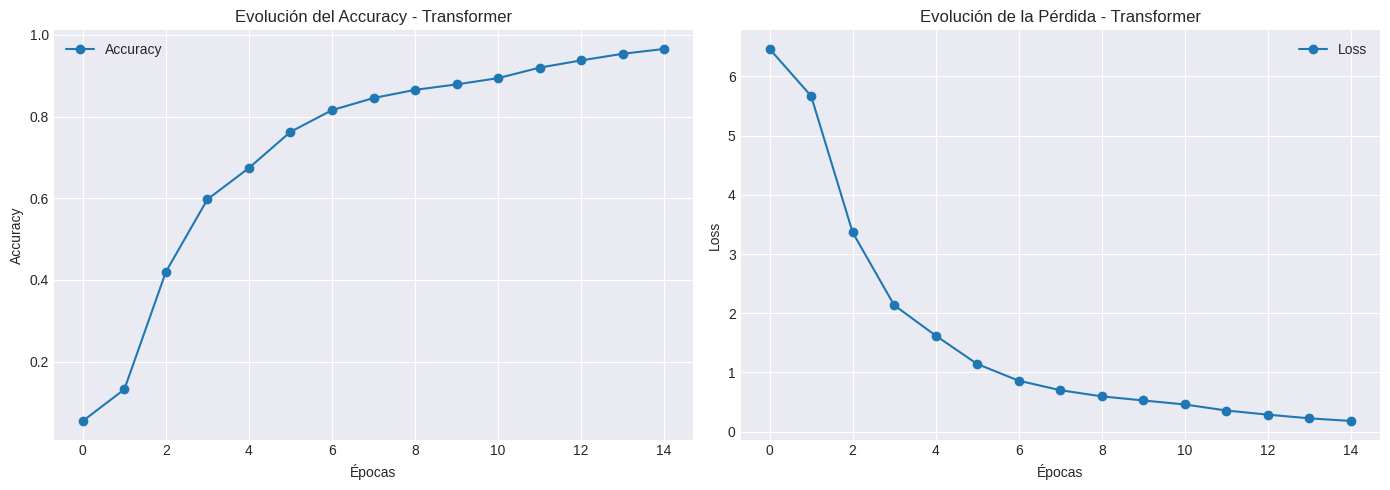

In [13]:
# ========================================
# GRÁFICA DE EVOLUCIÓN - TRANSFORMER V2
# ========================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_v2.history['accuracy'], label='Accuracy', marker='o')
axes[0].set_title('Evolución del Accuracy - Transformer')
axes[0].set_xlabel('Épocas')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_v2.history['loss'], label='Loss', marker='o')
axes[1].set_title('Evolución de la Pérdida - Transformer')
axes[1].set_xlabel('Épocas')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()